# Neural Network Risk Pipeline

This notebook is the presentation layer for the project's neural-network
pipeline. Model training, validation threshold selection, evaluation, and
artifact saving are owned by `ml/src/neural_network_model.py`.

The notebook loads the current dataset and the NN artifacts already generated by
that script. Running this notebook creates visuals only; it does not train or
overwrite the model.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = NOTEBOOK_DIR / "ml" / "notebooks"

ML_DIR = NOTEBOOK_DIR.parent
SRC_DIR = ML_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import neural_network_model as nn

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "axes.titleweight": "bold",
        "axes.labelweight": "semibold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

RISK_COLORS = {"LOW RISK": "#2563eb", "HIGH RISK": "#dc2626"}

print(f"Dataset: {nn.DATA_PATH}")
print(f"Metrics source: {nn.METRICS_PATH}")
print("Training source of truth: ml/src/neural_network_model.py")

Dataset: C:\Users\Admin\Desktop\import-risk-analysis-system\ml\data\processed\cleaned_dataset.csv
Metrics source: C:\Users\Admin\Desktop\import-risk-analysis-system\ml\models\neural_network_metrics.json
Training source of truth: ml/src/neural_network_model.py


## 1. Current Dataset and Safe Features

The notebook loads `ml/data/processed/cleaned_dataset.csv` through the same
function used by the reusable training script. Dataset validation checks required
columns, missing values, infinite values, and allowed target labels.

In [2]:
df = nn.load_dataset()
nn.validate_dataset(df)

dataset_summary = pd.DataFrame(
    {
        "Measure": ["Rows", "Columns", "Missing values in model fields", "Safe NN features"],
        "Value": [
            f"{len(df):,}",
            df.shape[1],
            int(df[nn.FEATURE_COLUMNS + [nn.TARGET_COLUMN]].isna().sum().sum()),
            len(nn.FEATURE_COLUMNS),
        ],
    }
)

display(dataset_summary)
display(pd.DataFrame({"Neural Network Feature": nn.FEATURE_COLUMNS}))
print(nn.LABEL_LEAKAGE_NOTE)

,Measure,Value
0,Rows,"263,821"
1,Columns,25
2,Missing values in model fields,0
3,Safe NN features,9


,Neural Network Feature
0,price_usd
1,weight_kg
2,length_m
3,width_m
4,height_m
5,volume_m3
6,max_dimension_m
7,dimension_sum_m
8,density_kg_m3


The final neural network is trained only on pre-risk shipment features. Tax-derived features and other variables used to construct the risk label are excluded from the neural network input to prevent target leakage.


## 2. Class Distribution

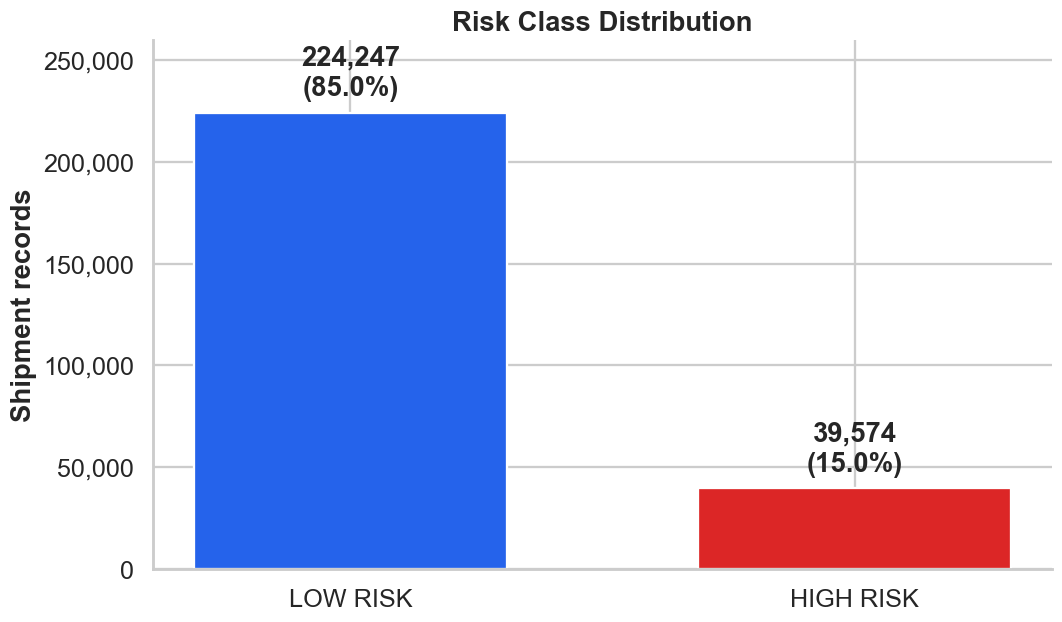

In [3]:
class_counts = (
    df[nn.TARGET_COLUMN]
    .value_counts()
    .reindex(["LOW RISK", "HIGH RISK"])
)
class_percentages = class_counts.div(class_counts.sum()).mul(100)

fig, ax = plt.subplots()
bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=[RISK_COLORS[label] for label in class_counts.index],
    width=0.62,
)
ax.set_title("Risk Class Distribution")
ax.set_xlabel("")
ax.set_ylabel("Shipment records")
ax.set_ylim(0, class_counts.max() * 1.16)
ax.yaxis.set_major_formatter(lambda value, _: f"{int(value):,}")

for bar, count, percentage in zip(bars, class_counts, class_percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + class_counts.max() * 0.025,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 3. Saved Training Configuration

The reusable training script uses a deterministic stratified 60/20/20 split and
fits `StandardScaler` on training data only. The values below document the
expected split without fitting preprocessing or training a model in this
notebook.

In [4]:
X_train, X_valid, X_test, y_train, y_valid, y_test = (
    nn.prepare_train_validation_test_data(df)
)

split_summary = pd.DataFrame(
    {
        "Split": ["Training", "Validation", "Held-out test"],
        "Rows": [len(X_train), len(X_valid), len(X_test)],
        "Share": [
            len(X_train) / len(df),
            len(X_valid) / len(df),
            len(X_test) / len(df),
        ],
        "High-risk share": [
            y_train.mean(),
            y_valid.mean(),
            y_test.mean(),
        ],
    }
)
split_summary["Share"] = split_summary["Share"].map(lambda value: f"{value:.1%}")
split_summary["High-risk share"] = split_summary["High-risk share"].map(
    lambda value: f"{value:.1%}"
)

display(split_summary)
print(f"Configured NN input features: {len(nn.FEATURE_COLUMNS)}")

,Split,Rows,Share,High-risk share
0,Training,158292,60.0%,15.0%
1,Validation,52764,20.0%,15.0%
2,Held-out test,52765,20.0%,15.0%


Configured NN input features: 9


## 4. Script-Generated Architecture Comparison

The following results are loaded from
`ml/models/neural_network_tuning_results.json`. They were generated by the
training script using training-only class weights, early stopping, and
validation-only threshold selection.

In [5]:
with nn.TUNING_PATH.open(encoding="utf-8") as tuning_file:
    tuning_results = json.load(tuning_file)

with nn.METRICS_PATH.open(encoding="utf-8") as metrics_file:
    final_metrics = json.load(metrics_file)

tuning_frame = pd.DataFrame(tuning_results)

print(f"Selected architecture: {final_metrics['name']}")
print(f"Selected threshold: {final_metrics['decision_threshold']:.4f}")
print(f"Training class weights: {final_metrics['class_weights']}")

Selected architecture: regularized_128_64_32
Selected threshold: 0.3467
Training class weights: {'0': 0.5882, '1': 3.0}


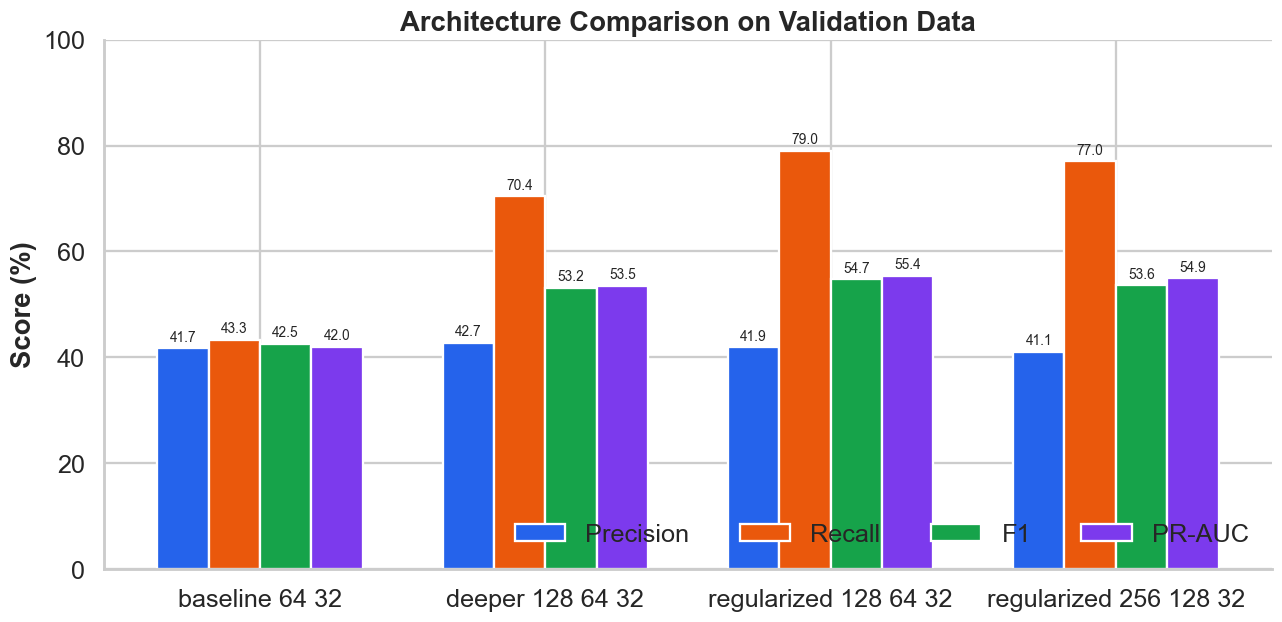

,name,layers,epochs_ran,decision_threshold,validation_accuracy,validation_precision,validation_recall,validation_f1_score,validation_pr_auc
0,baseline_64_32,"[64, 32]",8,0.608251,0.8242,0.4171,0.4328,0.4248,0.4198
1,deeper_128_64_32,"[128, 64, 32]",14,0.563717,0.8140,0.4271,0.7040,0.5317,0.5350
2,regularized_128_64_32,"[128, 64, 32]",17,0.346724,0.8038,0.4185,0.7903,0.5472,0.5538
3,regularized_256_128_32,"[256, 128, 32]",15,0.308905,0.7997,0.4106,0.7703,0.5357,0.5491


In [6]:
architecture_labels = tuning_frame["name"].str.replace("_", " ", regex=False)
comparison_columns = [
    ("validation_precision", "Precision"),
    ("validation_recall", "Recall"),
    ("validation_f1_score", "F1"),
    ("validation_pr_auc", "PR-AUC"),
]
x = np.arange(len(tuning_frame))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#2563eb", "#ea580c", "#16a34a", "#7c3aed"]

for index, ((column, label), color) in enumerate(zip(comparison_columns, colors)):
    offset = (index - 1.5) * width
    bars = ax.bar(
        x + offset,
        tuning_frame[column] * 100,
        width,
        label=label,
        color=color,
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{bar.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_title("Architecture Comparison on Validation Data")
ax.set_ylabel("Score (%)")
ax.set_xticks(x, architecture_labels)
ax.set_ylim(0, 100)
ax.legend(frameon=False, ncol=4, loc="lower right")
plt.tight_layout()
plt.show()

display(
    tuning_frame[
        [
            "name",
            "layers",
            "epochs_ran",
            "decision_threshold",
            "validation_accuracy",
            "validation_precision",
            "validation_recall",
            "validation_f1_score",
            "validation_pr_auc",
        ]
    ]
)

## 5. Saved Held-Out Test Evaluation

The final results below are read from `ml/models/neural_network_metrics.json`.
The notebook does not recalculate predictions or save artifacts.

In [7]:
metric_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "High-risk precision",
            "High-risk recall",
            "High-risk F1",
            "Precision-recall AUC",
        ],
        "Score": [
            final_metrics["accuracy"],
            final_metrics["precision"],
            final_metrics["recall"],
            final_metrics["f1_score"],
            final_metrics["pr_auc"],
        ],
    }
)
metric_summary["Score (%)"] = metric_summary["Score"].map(
    lambda value: f"{value * 100:.2f}%"
)

display(metric_summary[["Metric", "Score (%)"]])
print(f"Best architecture: {final_metrics['name']}")
print(f"Decision threshold: {final_metrics['decision_threshold']:.4f}")
print(f"Evaluation split: {final_metrics['evaluation_split']}")

,Metric,Score (%)
0,Accuracy,80.09%
1,High-risk precision,41.40%
2,High-risk recall,78.69%
3,High-risk F1,54.25%
4,Precision-recall AUC,54.96%


Best architecture: regularized_128_64_32
Decision threshold: 0.3467
Evaluation split: held_out_test


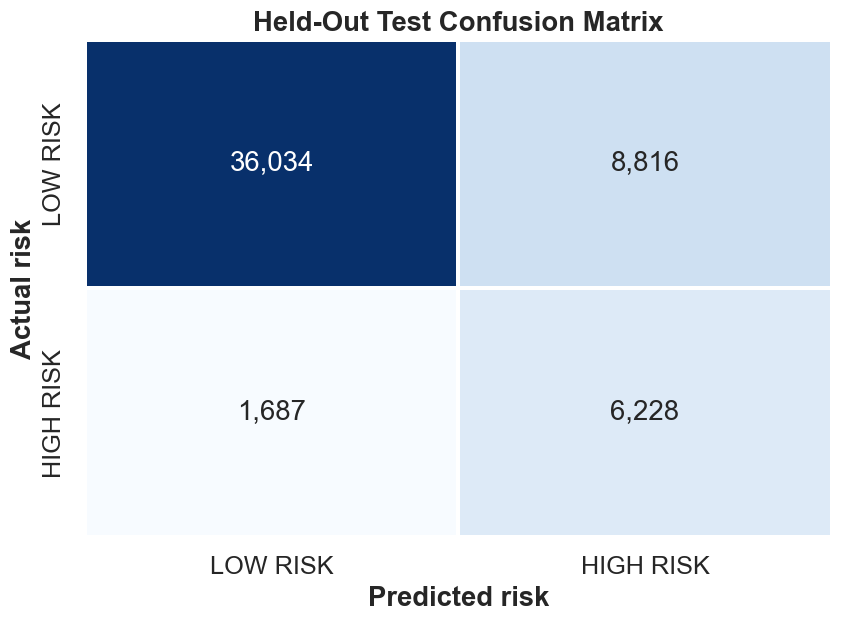

In [8]:
matrix = np.asarray(final_metrics["confusion_matrix"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    linewidths=1.5,
    linecolor="white",
    xticklabels=["LOW RISK", "HIGH RISK"],
    yticklabels=["LOW RISK", "HIGH RISK"],
    ax=ax,
)
ax.set_title("Held-Out Test Confusion Matrix")
ax.set_xlabel("Predicted risk")
ax.set_ylabel("Actual risk")
plt.tight_layout()
plt.show()

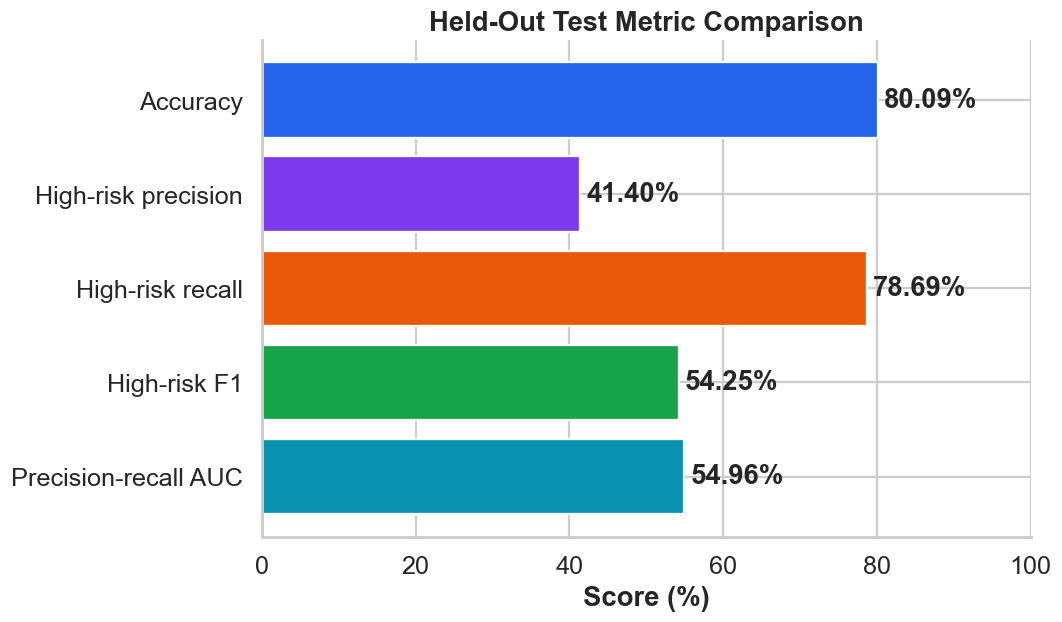

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
metric_plot = metric_summary.copy()
metric_plot["Score (%)"] = metric_plot["Score"] * 100
bars = ax.barh(
    metric_plot["Metric"],
    metric_plot["Score (%)"],
    color=["#2563eb", "#7c3aed", "#ea580c", "#16a34a", "#0891b2"],
)
ax.set_title("Held-Out Test Metric Comparison")
ax.set_xlabel("Score (%)")
ax.set_xlim(0, 100)
ax.invert_yaxis()

for bar in bars:
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}%",
        va="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 6. Saved Neural Network Artifacts

In [10]:
artifact_paths = [
    nn.MODEL_PATH,
    nn.SCALER_PATH,
    nn.METRICS_PATH,
    nn.TUNING_PATH,
    nn.REPORT_PATH,
]

artifact_summary = pd.DataFrame(
    {
        "Artifact": [path.name for path in artifact_paths],
        "Exists": [path.exists() for path in artifact_paths],
        "Size (KB)": [
            round(path.stat().st_size / 1024, 1) if path.exists() else 0
            for path in artifact_paths
        ],
    }
)
display(artifact_summary)

print("Presentation loaded from script-generated NN artifacts.")
print(nn.LABEL_LEAKAGE_NOTE)

,Artifact,Exists,Size (KB)
0,import_risk_neural_network.h5,True,205.5
1,import_risk_neural_network_scaler.joblib,True,1.1
2,neural_network_metrics.json,True,1.5
3,neural_network_tuning_results.json,True,4.7
4,neural_network_report.txt,True,1.1


Presentation loaded from script-generated NN artifacts.
The final neural network is trained only on pre-risk shipment features. Tax-derived features and other variables used to construct the risk label are excluded from the neural network input to prevent target leakage.
